In [78]:
import pandas as pd 
import numpy as np 
from datetime import timedelta
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [79]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
]
HIDDEN_LAYERS = [128, 64, 32]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0.1  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.BCEWithLogitsLoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.001  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0.0001  # Increase weight decay for regularization
EPOCHS = 3  # Reduce epochs to prevent overfitting
BATCH_SIZE = 256  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 1000  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 100  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping
LAG_DAYS = 7


In [ ]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\data\processed\ProcessedObservedData.csv')
#filter by opDiv CDC
data = data[data['OpDiv'] == 'CDC']
data.drop(columns=['curr_date'], inplace=True)
# Rename the index to 'date' since 'obs_date' is now the index
data.rename(columns={'obs_date': 'date'}, inplace=True)
data.head(10)
# Create a copy of the relevant columns to avoid SettingWithCopyWarning
data = data[['indicator', 'date']].copy()  # Replace 'observations' with the correct column name

data['seen'] = 1
data.head(10)

,indicator,date,seen
0,104.18.68.40,2025-01-01,1
1,104.248.125.97,2025-01-01,1
2,118.193.72.187,2025-01-01,1
3,118.193.72.187,2025-01-01,1
4,118.193.72.187,2025-01-01,1
5,118.193.72.187,2025-01-01,1
6,119.200.13.201,2025-01-01,1
7,119.200.13.201,2025-01-01,1
8,119.200.13.201,2025-01-01,1
9,119.200.13.201,2025-01-01,1


In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31934 entries, 0 to 31933
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   indicator  31934 non-null  object
 1   date       31934 non-null  object
 2   seen       31934 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 748.6+ KB


In [82]:
presence_matrix = data.pivot_table(
    index='indicator',    # one row per indicator
    columns='date',       # one column per date
    values='seen',        # values = 1 when present
    fill_value=0          # fill gaps with 0
)

presence_matrix = presence_matrix.sort_index(axis=1)
presence_matrix

date,2025-01-01,2025-01-02,2025-01-03,2025-01-04,2025-01-05,2025-01-06,2025-01-07,2025-01-08,2025-01-09,2025-01-10,...,2025-04-05,2025-04-06,2025-04-07,2025-04-08,2025-04-09,2025-04-10,2025-04-11,2025-04-12,2025-04-13,2025-04-14
indicator,,,,,,,,,,,,,,,,,,,,,
102.129.153.158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102.129.153.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102.129.153.71,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102.165.16.161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
102.68.39.251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
www.totem.tech,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
www.ultrasound-guided-injections.co.uk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
www.zerofox.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# ---------------------------
# Prepare sequence + labels
# ---------------------------
sequence_length = 30
predict_window = 7

X_sequences = []
y_labels = []

for indicator in presence_matrix.index:
    timeseries = presence_matrix.loc[indicator].values

    for i in range(len(timeseries) - sequence_length - predict_window):
        input_seq = timeseries[i:i + sequence_length]
        future_seq = timeseries[i + sequence_length:i + sequence_length + predict_window]
        label = 1 if future_seq.sum() > 0 else 0

        X_sequences.append(input_seq)
        y_labels.append(label)

# Convert to numpy arrays
X_sequences = np.array(X_sequences).reshape(-1, sequence_length, 1)
y_labels = np.array(y_labels)

# ---------------------------
# Split into train/val sets
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ---------------------------
# Create DataLoaders
# ---------------------------
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

#add columns to features
FEATURES.extend([f"lag_{i}" for i in range(sequence_length)])

# Confirm shapes (optional)
print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Test:", X_test.shape, y_test.shape)


Train: torch.Size([57727, 30, 1]) torch.Size([57727, 1])
Test: torch.Size([14432, 30, 1]) torch.Size([14432, 1])


In [84]:
# ----------------------------
# Customizable LSTM
# Model
# ----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)  # Only use the hidden state from the last time step
        out = self.fc(hidden[-1])  # Pass the last hidden state through a fully connected layer
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu


model = LSTMModel(
    input_size=1,  # input dimension is the number of features
    hidden_size=HIDDEN_LAYERS[0],  # use the first hidden layer size as the hidden size
    output_size=1,  # output size is 1 since we are predicting a single value
    num_layers=len(HIDDEN_LAYERS)  # number of layers is the length of HIDDEN_LAYERS
).to(device)

In [85]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 03 | Train Loss: 0.4380 | Test Loss: 0.4374


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


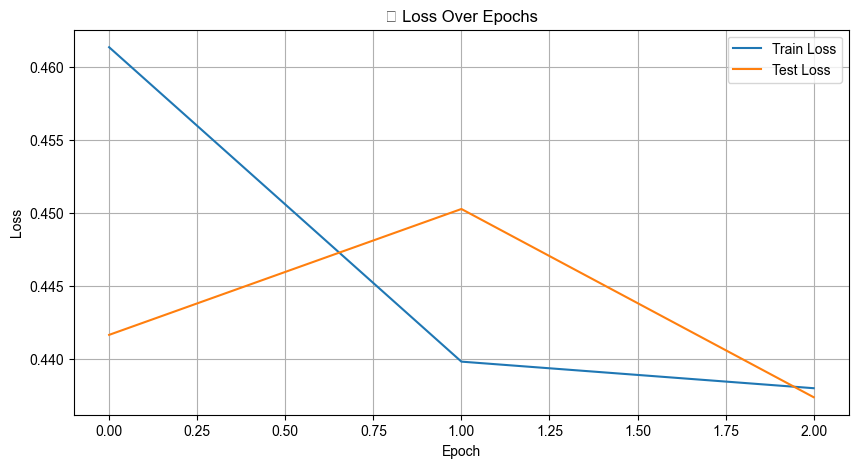

In [86]:
# Early stopping setup
best_val_loss = float("inf")
patience = 5
patience_counter = 0

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Reshape input to match LSTM expected input shape: (batch_size, sequence_length, input_size)
        # Ensure input shape matches LSTM expected input shape: (batch_size, sequence_length, input_size)
        # No need to unsqueeze here as the input is already in the correct shape

        preds = model(xb)  # should be shape: (batch_size, 1)

        # Ensure both preds and yb have the same shape
        if preds.ndim == 1:
            preds = preds.unsqueeze(1)  
        if yb.ndim == 1:
            yb = yb.unsqueeze(1)  

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average training loss
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----------------------
    # Validation
    # ----------------------
    model.eval()
    with torch.no_grad():
        # Move X_test and y_test to the same device as the model
        X_test_device = X_test.to(device)
        y_test_device = y_test.to(device)

        y_pred_test = model(X_test_device)
        test_loss = loss_fn(y_pred_test, y_test_device).item()
        test_losses.append(test_loss)

        # Early Stopping Logic
        if test_loss < BEST_LOSS:
            BEST_LOSS = test_loss
            PATIENCE_COUNTER = 0
            best_model_state = model.state_dict()
        else:
            PATIENCE_COUNTER += 1

        if PATIENCE_COUNTER >= PATIENCE:
            print(f"Early stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
            break


    # ----------------------
    # Early stopping logic
    # ----------------------
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1} — no improvement for {patience} epochs.")
            break
    # Logging
    
print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Load the best model state after training
model.load_state_dict(best_model_state)

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.rcParams['font.family'] = 'Arial'  # Set font family before plotting
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()